In [4]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

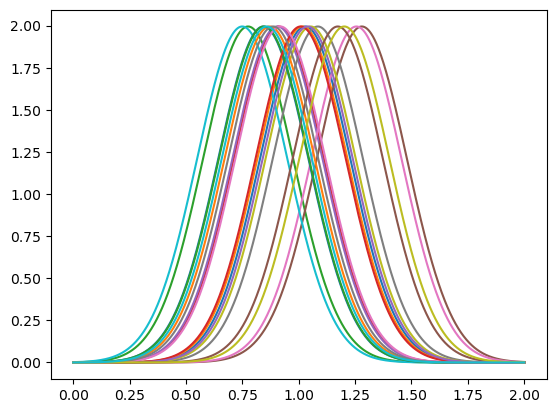

In [7]:
true_mu = 1
meas_err = 0.2 
N = 20
gen_meas = np.random.normal(loc=true_mu, scale=meas_err, size=N)
x_arr = np.linspace(0, 2, 1000)

fig, ax = plt.subplots()

for i in range(N):
    y_arr = norm.pdf(x_arr, gen_meas[i], meas_err)
    plt.plot(x_arr, y_arr)

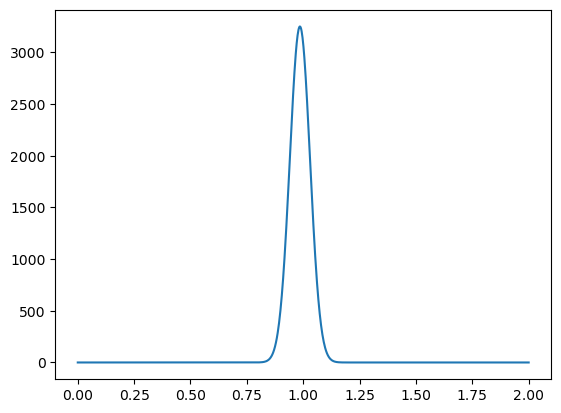

In [8]:
#total likelihood

tot_lik = np.ones(len(x_arr))

for i in range(N):
    tot_lik = tot_lik * norm.pdf(x_arr, gen_meas[i], meas_err)

fig, ax = plt.subplots()
plt.plot(x_arr, tot_lik)

In [27]:
max_idx = (np.argsort(tot_lik))[-1]
print('Solution: ', x_arr[max_idx])
print('Mean: ', np.mean(gen_meas))

Solution:  0.984984984984985
Mean:  0.9853136929144167


In [32]:
# fisher matrix check

log_lik = np.log10(tot_lik)
lik_2nd_diff = np.diff(log_lik, n=2)

est = (-lik_2nd_diff[max_idx])**0.5

sigma_mu = meas_err / np.sqrt(N)
print(est, '\n', sigma_mu)

0.029501334732172688 
 0.044721359549995794


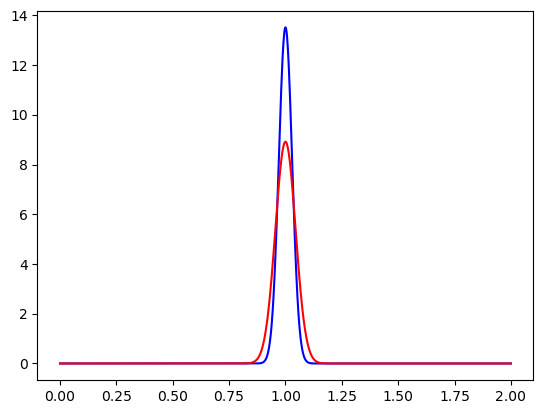

In [33]:
fig, ax = plt.subplots()
plt.plot(x_arr, norm.pdf(x_arr, true_mu, est), color='blue')
plt.plot(x_arr, norm.pdf(x_arr, true_mu, sigma_mu), color='red')